In [1]:
from fastai.vision.all import *
import numpy as np
import sys

np.set_printoptions(threshold=sys.maxsize)



/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [2]:
import pandas as pd
import os
import random

# Read with correct column names (competition expects BraTS21ID, MGMT_value)
df = pd.read_csv(
    "../input/rsna-miccai-brain-tumor-radiogenomic-classification/train_labels.csv",
    dtype={"BraTS21ID": str, "MGMT_value": int},
)

# Exclude known-bad cases (as recommended by competition)
df = df[~df["BraTS21ID"].isin(["00109", "00123", "00709"])].reset_index(drop=True)

df.head()



,BraTS21ID,MGMT_value
0,00642,0
1,00100,1
2,00309,0
3,00301,0
4,00464,0


In [3]:
import re


def natural_sort(l):
    convert = lambda text: int(text) if text.isdigit() else text.lower()
    alphanum_key = lambda key: [convert(c) for c in re.split("([0-9]+)", key)]
    return sorted(l, key=alphanum_key)




In [4]:
import pydicom
from pydicom.pixel_data_handlers.util import apply_voi_lut
from PIL import Image

INPUT = "../input/rsna-miccai-brain-tumor-radiogenomic-classification"

os.makedirs("./train", exist_ok=True)
os.makedirs("./test", exist_ok=True)


# Bugfix: ensure we select a valid FLAIR slice per subject (middle slice) and actually
# create one PNG for each subject folder.
def process_dicom(path, outpath):
    # Bugfix: pydicom.read_file was removed; use dcmread
    dicom = pydicom.dcmread(path)
    data = apply_voi_lut(dicom.pixel_array, dicom)
    if getattr(dicom, "PhotometricInterpretation", "") == "MONOCHROME1":
        data = np.amax(data) - data
    data = data.astype(np.float32)
    data = data - np.min(data)
    mx = np.max(data)
    if mx > 0:
        data = data / mx
    data = (data * 255.0).clip(0, 255).astype(np.uint8)
    Image.fromarray(data, mode="L").save(outpath)


def get_middle_flair_dcm(subject_dir):
    flair_dir = os.path.join(subject_dir, "FLAIR")
    if not os.path.isdir(flair_dir):
        return None
    files = [f for f in os.listdir(flair_dir) if f.lower().endswith(".dcm")]
    if not files:
        return None
    files = natural_sort(files)
    return os.path.join(flair_dir, files[len(files) // 2])


def build_png_dataset(input_dir, dataset="train"):
    root = os.path.join(input_dir, dataset)
    ids = natural_sort(
        [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]
    )
    created = 0
    for cur_id in ids:
        subject_dir = os.path.join(root, cur_id)
        dcm_path = get_middle_flair_dcm(subject_dir)
        if dcm_path is None:
            continue
        outpath = os.path.join(f"./{dataset}", f"{cur_id}.png")
        if not os.path.exists(outpath):
            try:
                process_dicom(dcm_path, outpath)
                created += 1
            except Exception:
                # Skip corrupt/unreadable studies
                continue
    return created


created_train = build_png_dataset(INPUT, "train")
created_test = build_png_dataset(INPUT, "test")
print(f"PNGs created: train={created_train}, test={created_test}")



/tmp/ipykernel_11/753342725.py:25: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(data, mode="L").save(outpath)


PNGs created: train=526, test=59


In [5]:
# Bugfix: only keep training rows that actually have extracted PNGs, otherwise fastai fails on open.
df["file"] = df["BraTS21ID"].apply(lambda x: f"./train/{x}.png")
df = df[df["file"].apply(os.path.exists)].reset_index(drop=True)

# Keep the label column as int for classification
df["MGMT_value"] = df["MGMT_value"].astype(int)

df.head()



,BraTS21ID,MGMT_value,file
0,00642,0,./train/00642.png
1,00100,1,./train/00100.png
2,00309,0,./train/00309.png
3,00301,0,./train/00301.png
4,00464,0,./train/00464.png


In [6]:
df



,BraTS21ID,MGMT_value,file
0,00642,0,./train/00642.png
1,00100,1,./train/00100.png
2,00309,0,./train/00309.png
3,00301,0,./train/00301.png
4,00464,0,./train/00464.png
...,...,...,...
518,00404,1,./train/00404.png
519,00014,1,./train/00014.png
520,00529,1,./train/00529.png
521,00285,1,./train/00285.png


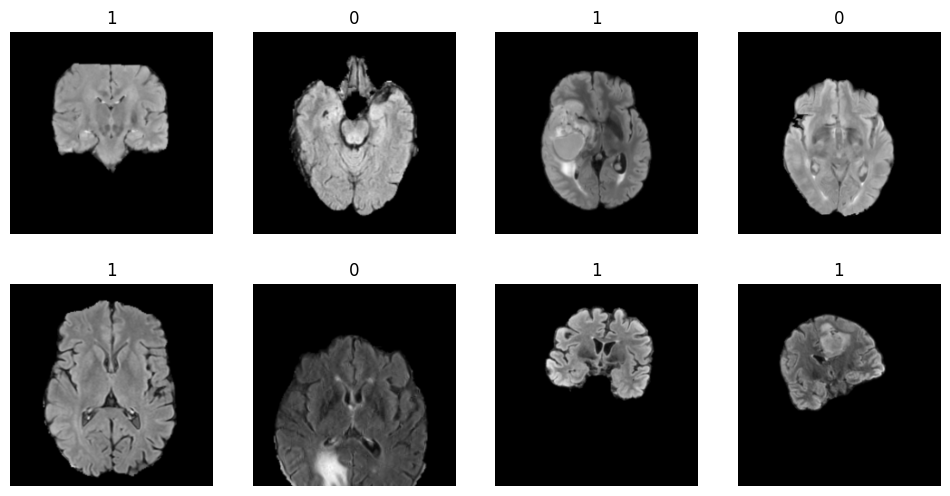

In [7]:
# Bugfix: Ensure proper label_col and fn_col after renaming, and define y_block for classification.
# Core approach preserved: fastai ImageDataLoaders.from_df + Resize.
dls = ImageDataLoaders.from_df(
    df,
    valid_pct=0.2,
    seed=42,
    fn_col="file",
    label_col="MGMT_value",
    y_block=CategoryBlock,
    item_tfms=Resize(224),
    bs=64,
    path="",
)

dls.show_batch(max_n=8)



In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# Bugfix: original Net output was 10 classes and used ReLU on final layer,
# which breaks probability calibration for AUC. Keep same core architecture,
# but set output to 2 logits for binary classification and remove final ReLU.
class Net(nn.Module):
    def __init__(self, pretrained=False):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)  # logits
        return x




In [9]:
# Core approach preserved: cnn_learner + fit_one_cycle.
# Bugfix: use ROC AUC metric appropriate for probability ranking.
learn = cnn_learner(
    dls,
    Net,
    metrics=[RocAucBinary()],
    model_dir="/tmp/model/",
)

# Keep fp16 as in original (no approximations beyond that were requested/added)
learn = learn.to_fp16()

learn



/usr/local/lib/python3.11/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")


SuggestedLRs(valley=0.0012022644514217973)

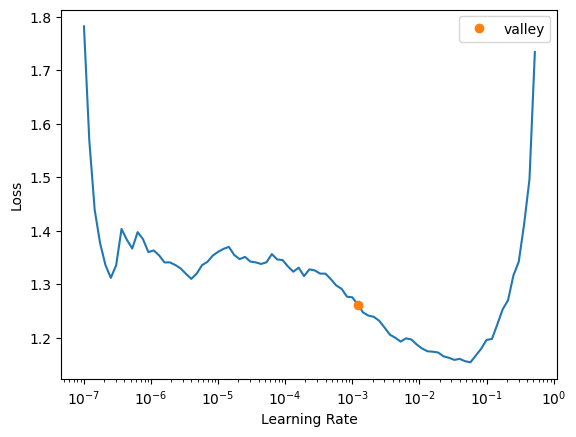

In [10]:
learn.lr_find()



In [11]:
# Keep original training schedule/epochs.
learn.fit_one_cycle(10, lr_max=1e-2, cbs=ShortEpochCallback())



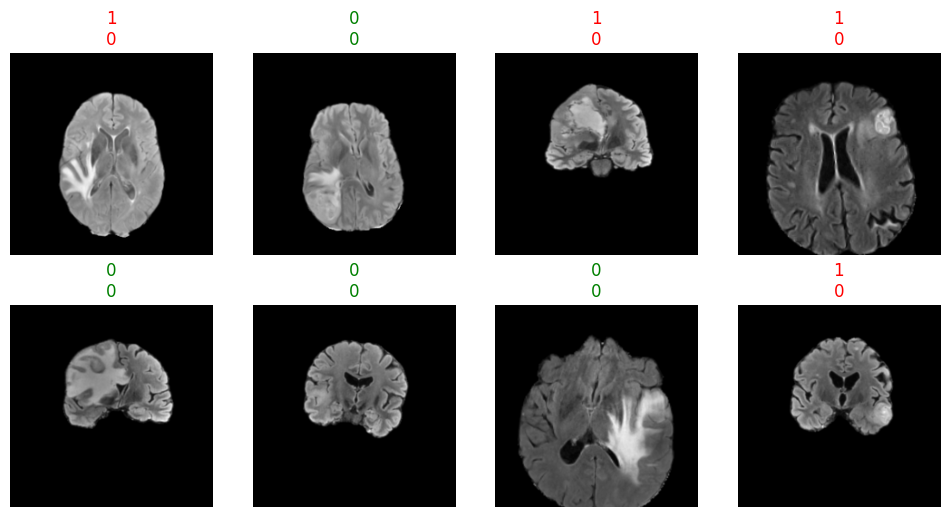

In [12]:
learn.show_results(max_n=8)



In [13]:
# Build test dataframe from sample_submission to guarantee correct row count + ordering.
sample_path = (
    "../input/rsna-miccai-brain-tumor-radiogenomic-classification/sample_submission.csv"
)
sub = pd.read_csv(sample_path, dtype={"BraTS21ID": str, "MGMT_value": float})

# Ensure corresponding test PNGs exist (created in cell 4)
sub["file"] = sub["BraTS21ID"].apply(lambda x: f"./test/{x}.png")

missing = sub[~sub["file"].apply(os.path.exists)]
if len(missing) > 0:
    print(f"Warning: missing {len(missing)} test PNGs; those will get default 0.5")

sub.head()



,BraTS21ID,MGMT_value,file
0,00356,0.5,./test/00356.png
1,00140,0.5,./test/00140.png
2,00757,0.5,./test/00757.png
3,00275,0.5,./test/00275.png
4,00570,0.5,./test/00570.png


In [14]:
# Predict probabilities for class "1" (MGMT_value=1)
preds = []
for fp in sub["file"].tolist():
    if not os.path.exists(fp):
        preds.append(0.5)
        continue
    pred = learn.predict(fp)
    # pred[2] is probability tensor for each class
    prob_1 = float(pred[2][1].item())
    preds.append(prob_1)

sub["MGMT_value"] = preds

sub[["BraTS21ID", "MGMT_value"]].head()



,BraTS21ID,MGMT_value
0,00356,0.272775
1,00140,0.275568
2,00757,0.252614
3,00275,0.262464
4,00570,0.228630


In [15]:
# Write valid submission with correct columns and exact number of rows.
out_path = "submission.csv"
sub[["BraTS21ID", "MGMT_value"]].to_csv(out_path, index=False)
print(f"Wrote {out_path} with shape {sub.shape}")
print(sub[["MGMT_value"]].describe())

Wrote submission.csv with shape (59, 3)
       MGMT_value
count   59.000000
mean     0.257840
std      0.016409
min      0.228630
25%      0.246579
50%      0.257859
75%      0.268797
max      0.309141
